#Convolutional Neural Network (CNN)

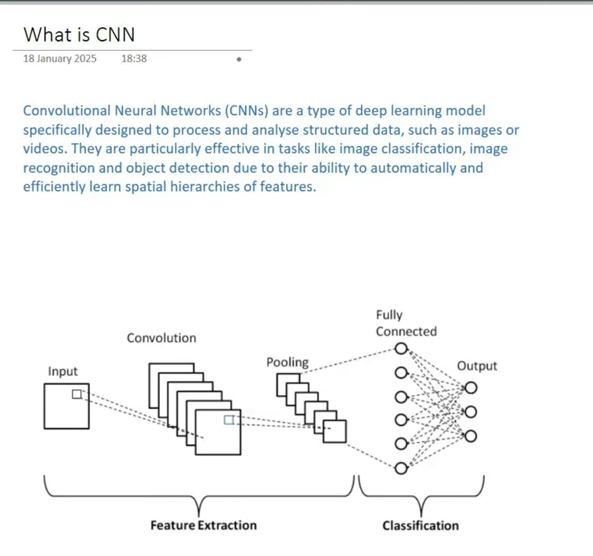

**CNN best for grid based datset like images**
* Cnn is used for Computer vision task
* Image Classification task
* Object Detection task
* Image Segmentation

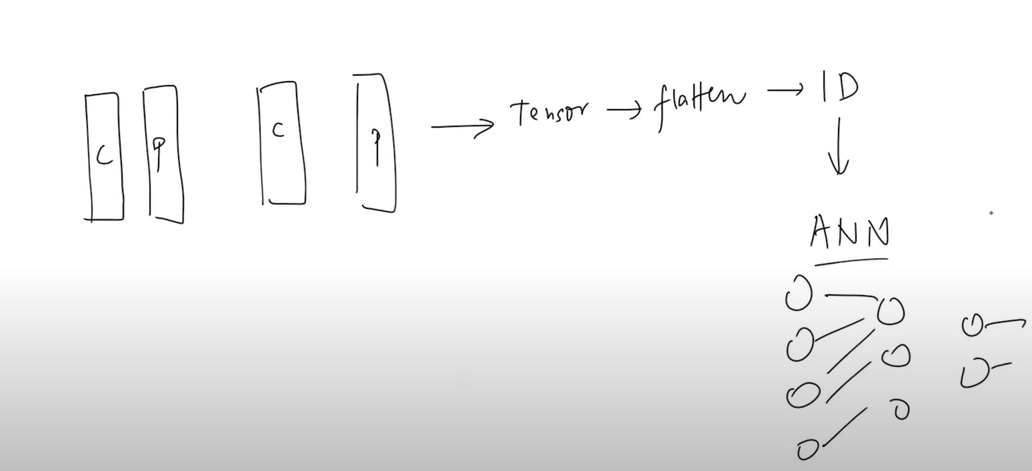

#Our CNN Architecture:
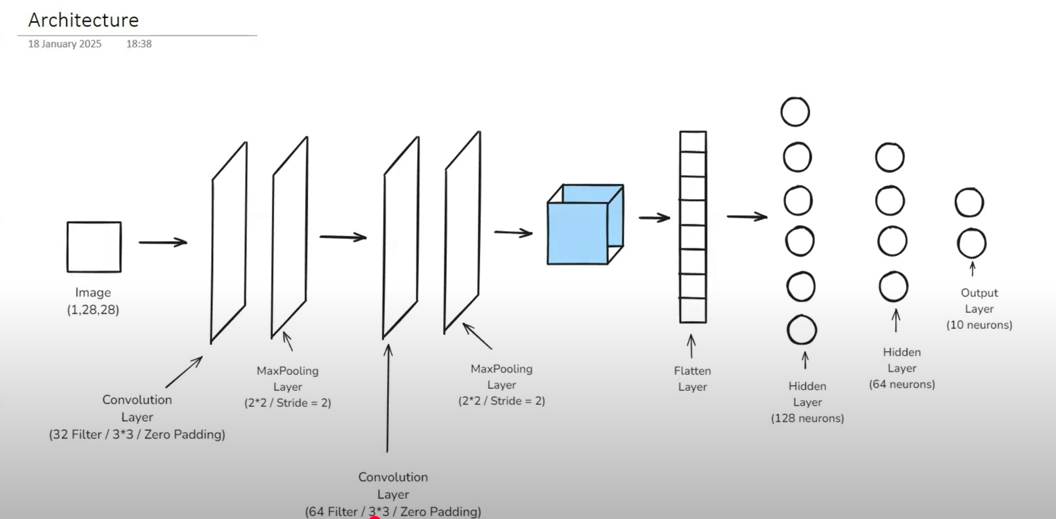

In [36]:
!pip install optuna

In [37]:
import pandas as pd
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

In [38]:
#random seed for reporducibility
torch.manual_seed(42)

In [39]:
#device Agnostic code
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [40]:
!kaggle datasets download -d zalando-research/fashionmnist

Dataset URL: https://www.kaggle.com/datasets/zalando-research/fashionmnist
License(s): other
fashionmnist.zip: Skipping, found more recently modified local copy (use --force to force download)


In [41]:
!unzip fashionmnist.zip

Archive:  fashionmnist.zip
replace fashion-mnist_test.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
replace fashion-mnist_train.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
  inflating: fashion-mnist_train.csv  
replace t10k-images-idx3-ubyte? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

In [42]:
df = pd.read_csv('/content/fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [43]:
df.shape

(60000, 785)

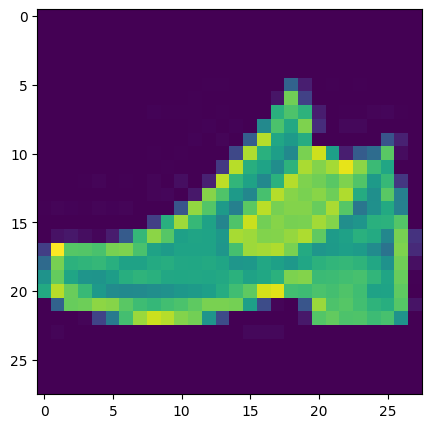

In [44]:
plt.figure(figsize=[15,5])
img = df.iloc[1, 1:].values.reshape(28, 28)
plt.imshow(img)

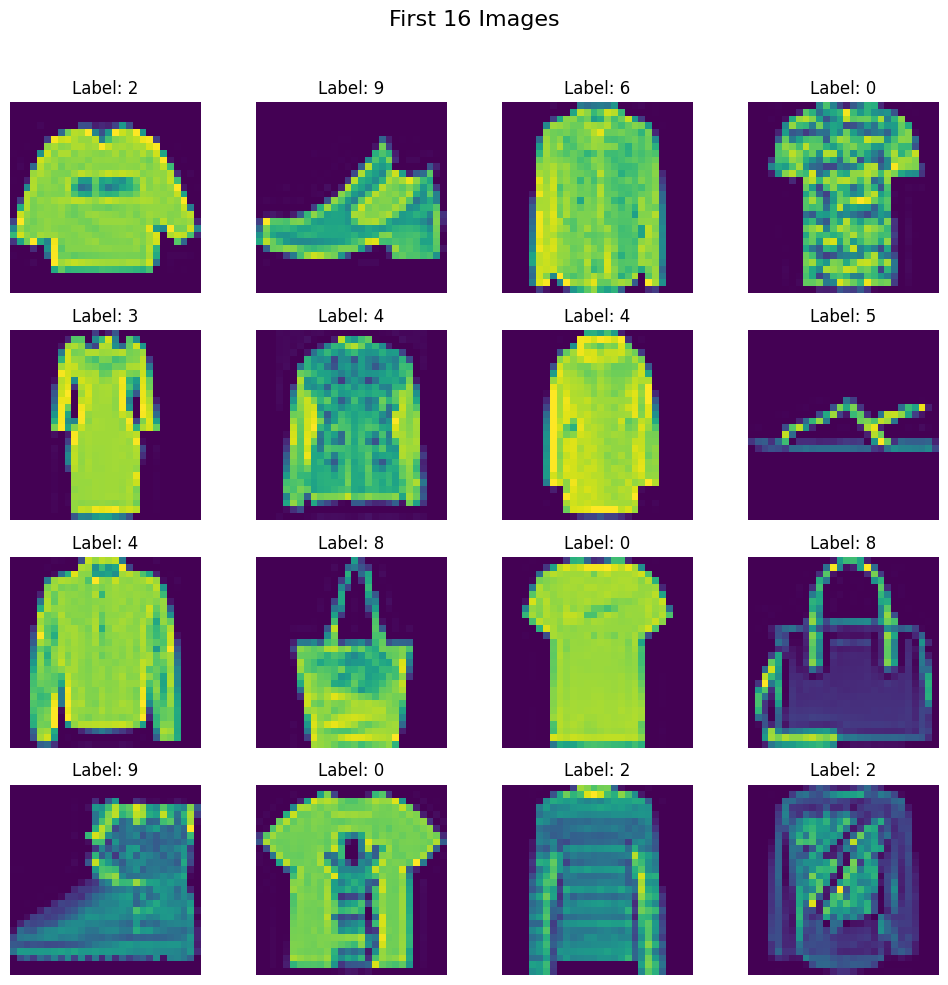

In [45]:
# Create a 4x4 grid of images
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
fig.suptitle("First 16 Images", fontsize=16)

# Plot the first 16 images from the dataset
for i, ax in enumerate(axes.flat):
    img = df.iloc[i, 1:].values.reshape(28, 28)  # Reshape to 28x28
    ax.imshow(img)  # Display in grayscale
    ax.axis('off')  # Remove axis for a cleaner look
    ax.set_title(f"Label: {df.iloc[i, 0]}")  # Show the label

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to fit the title
plt.show()


In [46]:
# train test split

X = df.iloc[:, 1:].values
y = df.iloc[:, 0].values

In [47]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [48]:
X_train = X_train/255.0
X_test = X_test/255.0

#Data Augmentation to Reduce Overfitting

In [49]:
from torchvision import transforms
#Data Augmentation for training dataset
train_transform=transforms.Compose(
    [transforms.ToPILImage(), #transform numpy array or tensor to PIL (python image library) image so further augmentation can apply
    transforms.RandomRotation(10), #Randomly rotates the image by up to ±10 degrees.
    transforms.RandomHorizontalFlip(p=0.5), #Randomly flips the image horizontally with a 50% probability (p=0.5).
    transforms.RandomAffine(0,translate=(0.1,0.1)), #The first parameter (0) means no rotation or shear is applied,The translate=(0.1, 0.1) part means the image can be randomly shifted by up to 10% in both horizontal  and vertical directions.
    transforms.ToTensor()]
    )
#Data Augmentation for Testing Dataset
test_transform=transforms.Compose(
   [ transforms.ToPILImage(),
    transforms.ToTensor()]
)

In [50]:
class CustomDataset(Dataset):

  def __init__(self, features, labels,transform=None):

    # Convert to PyTorch tensors
    self.features = torch.tensor(features, dtype=torch.float32).reshape(-1,1,28,28) #reshaping it from 1d to 2d batch_size,channel,height,width
    self.labels = torch.tensor(labels, dtype=torch.long)
    self.transform=transform

  def __len__(self):
    return len(self.features)

  def __getitem__(self, index):
    feature, label = self.features[index], self.labels[index]
    if self.transform:
      feature = self.transform(feature.squeeze(0).numpy())  # Apply transform
    return feature, label


In [51]:
#Use augmentation in dat
train_dataset=CustomDataset(X_train,y_train,transform=train_transform)
test_dataset=CustomDataset(X_test,y_test,transform=test_transform)


In [77]:
len(train_dataset)

48000

In [78]:
len(test_dataset)

12000

In [52]:
class MyCnn(nn.Module):
  def __init__(self,input_features):
    super().__init__()
    self.features=nn.Sequential(
        #1st block
        nn.Conv2d(in_channels=input_features,out_channels=32,kernel_size=3,padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(32),
        nn.MaxPool2d(kernel_size=2,stride=2),

        #2nd Block
        nn.Conv2d(in_channels=32,out_channels=64,kernel_size=3,padding='same'),
        nn.ReLU(),
        nn.BatchNorm2d(64),
        nn.MaxPool2d(kernel_size=2,stride=2)
    )
    self.classification=nn.Sequential(
        #Flatten the output from last layer before Dense Layer
        nn.Flatten(),
        nn.Linear(64*7*7,128),
        nn.ReLU(),
        nn.Dropout(p=0.4),

        nn.Linear(128,64),
        nn.ReLU(),
        nn.Dropout(p=0.4),

        nn.Linear(64,10)
    )

  def forward(self,x):
    x=self.features(x)
    x=self.classification(x)
    return x

In [69]:
class DynamicCnn(nn.Module):
  def __init__(self,num_conv,num_filters,kernal_size,num_fclayers,fclayers_size,dropout_rate):

    super().__init__()
    layers=[] #to append layers based on optuna choice
    in_channels=1 #gray scale image has 1 channel

    #first conv layers sequential append to list
    for _ in range(num_conv):
      layers.append(nn.Conv2d(in_channels=in_channels,out_channels=num_filters, kernel_size=kernal_size ,padding='same'))
      layers.append(nn.ReLU())
      layers.append(nn.BatchNorm2d(num_filters))
      layers.append(nn.MaxPool2d(kernel_size=2,stride=2))
      in_channels=num_filters #update in channel for next layer

    self.features=nn.Sequential(*layers)

    #flatten the input
    fc_layer=[nn.Flatten()]
    in_size=num_filters * (28 // (2 ** num_conv)) ** 2

    for _ in range(num_fclayers):
      fc_layer.append(nn.Linear(in_features=in_size,out_features=fclayers_size))
      fc_layer.append(nn.ReLU())
      fc_layer.append(nn.Dropout(dropout_rate))
      in_size=fclayers_size
    fc_layer.append(nn.Linear(in_features=in_size,out_features=10)) #output layer for 10 classes

    self.classifier=nn.Sequential(*fc_layer)

  def forward(self,x):
    x=self.features(x)
    x=self.classifier(x)
    return x

* **trial.suggest_int(name, low, high, step=1)** for integer value
* **trial.suggest_uniform(name, low, high)** for float point value
* **trial.suggest_loguniform(name, low, high)** for float point value but log uniform distribution
* **trial.suggest_categorical(name, choices)** for Suggests a discrete value from a predefined list of options


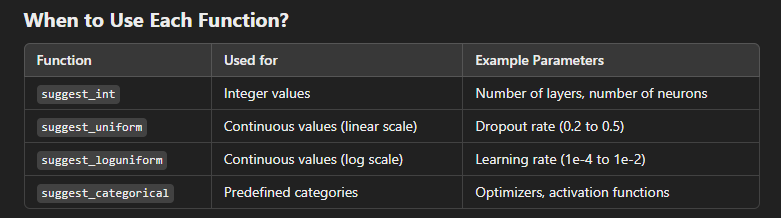

In [73]:
import optuna
def objective(trial):
  #HyperParameters to tune
  #cnn layers
  num_conv=trial.suggest_int('num_conv',1,3)
  num_filters=trial.suggest_categorical('num_filters',[16,32,64,128])
  kernal_size=trial.suggest_categorical('kernal_size',[3,5])
  #dense layers
  num_fclayers=trial.suggest_int('num_fclayers',1,3)
  fclayers_size=trial.suggest_categorical('fclayers_size',[64,128,256])
  #dropout weights
  dropout_rate=trial.suggest_uniform('dropout_rate',0.2,0.5)
  #weight decay regularizatoin
  weight_decay=trial.suggest_loguniform('weight_decay',1e-5,1e-2)
  #learning rate
  learning_rate=trial.suggest_loguniform('learning_rate',1e-4,1e-2)
  optimizer_name=trial.suggest_categorical('optimizer_name',['SGD','Adam','RMSprop'])
  #batch_size
  batch_size=trial.suggest_categorical('batch_size',[32,64,128])
  #epochs
  num_epochs=trial.suggest_int('num_epochs',10,30)


  #Model
  model=DynamicCnn(num_conv,num_filters,kernal_size,num_fclayers,fclayers_size,dropout_rate).to(device)

  #Data Loader
  train_loader=DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
  test_loader=DataLoader(test_dataset,batch_size=batch_size,shuffle=True)

  #Optimizer
  if optimizer_name=='SGD':
    optimizer=optim.SGD(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  elif optimizer_name=='Adam':
    optimizer=optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  elif optimizer_name=='RMSprop':
    optimizer=optim.RMSprop(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
  #Loss function
  criterion=nn.CrossEntropyLoss()

  #Training Loop
  for epoch in range(num_epochs):
    model.train()
    for batch_feature,batch_label in train_loader:
      batch_feature,batch_label=batch_feature.to(device),batch_label.to(device)
      optimizer.zero_grad()
      y_pred=model(batch_feature)
      loss=criterion(y_pred,batch_label)
      loss.backward()
      optimizer.step()

  #Validation loop
  model.eval()
  correct=0
  total=0
  with torch.no_grad():
    for batch_feature,batch_label in test_loader:
      batch_feature,batch_label=batch_feature.to(device),batch_label.to(device)
      y_pred=model(batch_feature)
      _, predicted = torch.max(y_pred, 1) #return value and index
      total+=batch_label.size(0)
      correct+=(predicted==batch_label).sum().item()
  acc=correct/total
  return acc

# **What is a pruner?**
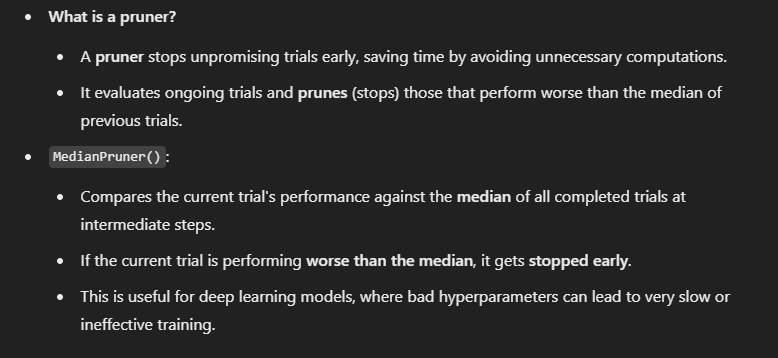

In [ ]:
#optuna study
pruner=optuna.pruners.MedianPruner()
study=optuna.create_study(direction='maximize',pruner=pruner)
study.optimize(objective,n_trials=50)

[I 2025-03-05 06:23:38,407] A new study created in memory with name: no-name-28afddd3-3eca-4e32-8c15-9f283ab5fbbf
<ipython-input-73-26c44b5ce7dd>:12: FutureWarning: suggest_uniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float instead.
  dropout_rate=trial.suggest_uniform('dropout_rate',0.2,0.5)
<ipython-input-73-26c44b5ce7dd>:14: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  weight_decay=trial.suggest_loguniform('weight_decay',1e-5,1e-2)
<ipython-input-73-26c44b5ce7dd>:16: FutureWarning: suggest_loguniform has been deprecated in v3.0.0. This feature will be removed in v6.0.0. See https://github.com/optuna/optuna/releases/tag/v3.0.0. Use suggest_float(..., log=True) instead.
  learning_rate=trial.suggest_loguniform('learning_rat

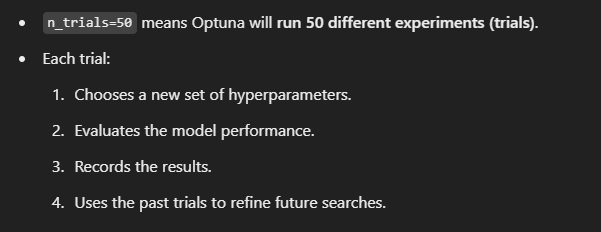

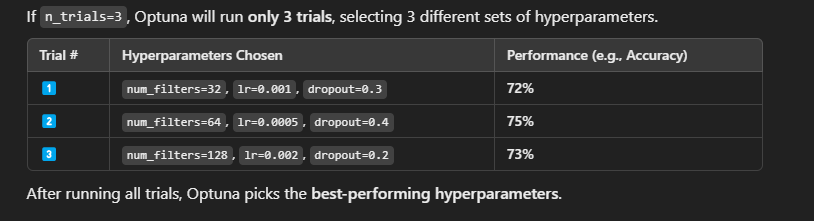

In [ ]:
#best hyperparameters and accuracy
print("Best hyperparameters:", study.best_params)
print("Best accuracy:", study.best_value)